# Exploration du corpus médical — semaine 1

**Projet** : POC d'agent d'aide au triage médical — Centre Hospitalier Saint-Aurélien
**Objectif du notebook** : caractériser les corpus disponibles, vérifier qu'ils
permettent réellement de construire un jeu de triage, et contrôler visuellement
la chaîne d'anonymisation.

Ce notebook **n'implémente aucune logique** : il importe les modules de `src/triage/`
pour que les mêmes traitements tournent en exploration, en production et sous CI.

**Prérequis** — corpus téléchargé :

```python
from triage.data.ingest import telecharger
telecharger("mediqal")
```

| Source | Langue | Licence | Rôle |
|---|---|---|---|
| `ANR-MALADES/MediQAl` | français | CC-BY-4.0 | cas cliniques et QCM |
| `TsinghuaC3I/UltraMedical-Preference` | anglais | MIT | paires préférentielles (DPO) |


In [1]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RACINE / "src"))

# Palette validée (séparation CVD ΔE 24,7 — au-delà du seuil de 8).
SURFACE, ENCRE, ENCRE_2 = "#fcfcfb", "#0b0b0b", "#52514e"
BLEU, ORANGE = "#2a78d6", "#eb6834"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "figure.dpi": 110,
    "text.color": ENCRE, "axes.labelcolor": ENCRE_2, "axes.titlecolor": ENCRE,
    "xtick.color": ENCRE_2, "ytick.color": ENCRE_2,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#d9d8d3",
    "axes.grid": True, "grid.color": "#eceae4", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 10, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlepad": 14,
})

BRUT = RACINE / "data" / "raw"
print("corpus disponibles :", len(list(BRUT.glob("*.parquet"))), "fichiers")

corpus disponibles : 7 fichiers


## 1. Volumétrie

MediQAl se décline en trois configurations : questions ouvertes (`oeq`),
QCM à réponse unique (`mcqu`) et QCM à réponses multiples (`mcqm`).

In [2]:
corpus = {}
for f in sorted(BRUT.glob("mediqal__*.parquet")):
    _, config, split = f.stem.split("__")
    corpus[(config, split)] = pd.read_parquet(f)

volumetrie = (
    pd.DataFrame(
        [{"config": k[0], "split": k[1], "lignes": len(v)} for k, v in corpus.items()]
    )
    .pivot(index="config", columns="split", values="lignes")
    .fillna(0).astype(int)
)
volumetrie["total"] = volumetrie.sum(axis=1)
volumetrie.loc["TOTAL"] = volumetrie.sum()
volumetrie

split,test,train,validation,total
config,,,,
mcqm,3384,5767,1466,10617
mcqu,4343,10113,2561,17017
oeq,4969,0,0,4969
TOTAL,12696,15880,4027,32603


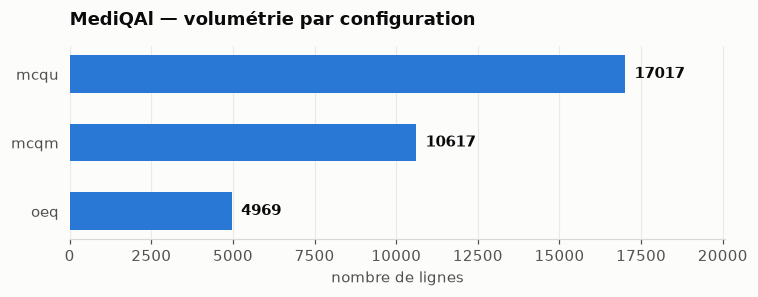

In [3]:
donnees = volumetrie.drop(index="TOTAL")["total"].sort_values()

fig, ax = plt.subplots(figsize=(7, 2.8))
barres = ax.barh(donnees.index, donnees.values, color=BLEU, height=0.55)
ax.bar_label(barres, fmt="%d", padding=6, color=ENCRE, fontweight="bold")
ax.set_title("MediQAl — volumétrie par configuration", loc="left")
ax.set_xlabel("nombre de lignes")
ax.set_xlim(0, donnees.max() * 1.18)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", visible=False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

## 2. De quoi ces cas cliniques parlent-ils ?

Question décisive : le corpus couvre-t-il l'**urgence**, qui est le domaine du projet ?

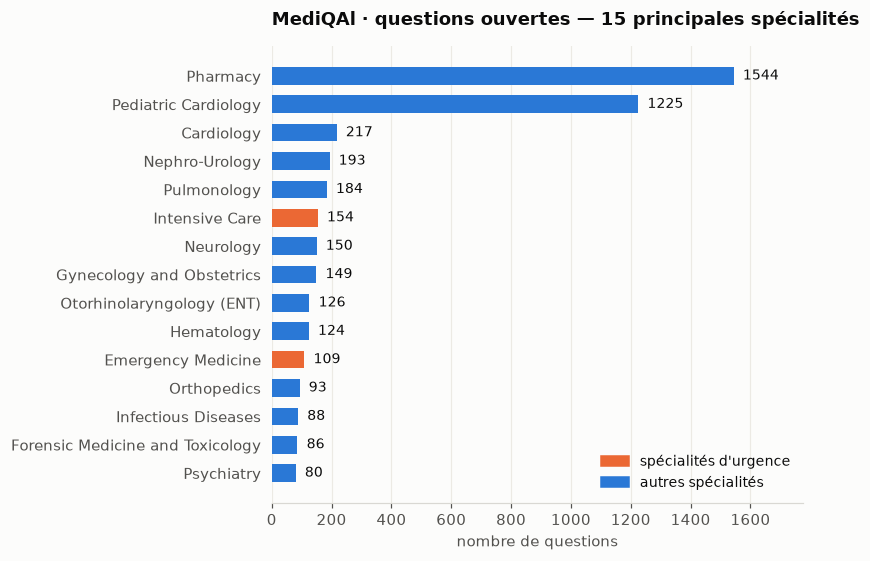

part des questions relevant de l'urgence : 5.3 %


In [4]:
oeq = corpus[("oeq", "test")]
SPECIALITES_URGENCE = {"Emergency Medicine", "Intensive Care"}

top = oeq.medical_subject.value_counts().head(15).sort_values()
couleurs = [ORANGE if s in SPECIALITES_URGENCE else BLEU for s in top.index]

fig, ax = plt.subplots(figsize=(7.5, 5.2))
barres = ax.barh(top.index, top.values, color=couleurs, height=0.62)
ax.bar_label(barres, fmt="%d", padding=6, color=ENCRE, fontsize=9)
ax.set_title("MediQAl · questions ouvertes — 15 principales spécialités", loc="left")
ax.set_xlabel("nombre de questions")
ax.set_xlim(0, top.max() * 1.15)
ax.grid(axis="y", visible=False)
ax.tick_params(left=False)

poignees = [
    plt.Rectangle((0, 0), 1, 1, color=ORANGE),
    plt.Rectangle((0, 0), 1, 1, color=BLEU),
]
ax.legend(poignees, ["spécialités d'urgence", "autres spécialités"],
          loc="lower right", frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

part = oeq.medical_subject.isin(SPECIALITES_URGENCE).mean()
print(f"part des questions relevant de l'urgence : {100 * part:.1f} %")

**Constat** — l'urgence est très minoritaire. Le corpus est dominé par la
pharmacie et la cardiologie pédiatrique. Il apporte de la **connaissance médicale
en français**, pas des situations de triage.

## 3. Le corpus contient-il les signaux nécessaires au triage ?

Le schéma de métadonnées du projet prévoit `symptômes`, `antécédents`,
`constantes` et `niveau_priorite`. Vérifions ce qui est réellement présent dans
les cas cliniques.

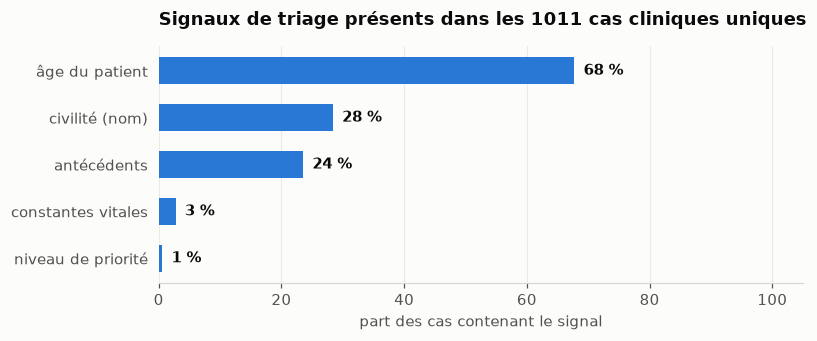

In [5]:
cas_uniques = oeq.drop_duplicates("clinical_case").clinical_case.dropna()

SIGNAUX = {
    "âge du patient": r"\b\d{1,3}\s*ans\b",
    "civilité (nom)": r"\b(?:M(?:r|me)\.?|Monsieur|Madame|Mademoiselle)\b",
    "antécédents": r"ATCD|antéc",
    "constantes vitales": r"\b(?:FC|PA|TA|FR|SpO2|SaO2)\s*[=:]",
    "niveau de priorité": r"\b(?:tri(?:age)?|CIMU|FRENCH|priorit)\w*\s*[=:]?\s*[123]",
}
couverture = pd.Series(
    {nom: cas_uniques.str.contains(motif, case=False, regex=True).mean()
     for nom, motif in SIGNAUX.items()}
).sort_values() * 100

fig, ax = plt.subplots(figsize=(7.5, 3.2))
barres = ax.barh(couverture.index, couverture.values, color=BLEU, height=0.58)
ax.bar_label(barres, fmt="%.0f %%", padding=6, color=ENCRE, fontweight="bold")
ax.set_title(f"Signaux de triage présents dans les {len(cas_uniques)} cas cliniques uniques",
             loc="left")
ax.set_xlabel("part des cas contenant le signal")
ax.set_xlim(0, 105)
ax.grid(axis="y", visible=False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

**Conclusion structurante du lot données.**

L'âge est presque toujours là, les antécédents une fois sur quatre, mais les
**constantes vitales sont quasi absentes** et **aucun niveau de priorité n'est
annoté**. MediQAl ne peut donc pas servir seul de jeu de triage.

D'où la composition retenue (`docs/03c-plan-composition-dataset.md`) : les corpus
fournissent le socle de connaissance médicale, et un bloc de **cas de triage
structurés** apporte le couple `constantes → priorité` sans lequel le taux de
sous-triage — la métrique de sécurité du projet — serait impossible à mesurer.

La forte présence de **civilités** justifie par ailleurs l'anonymisation, examinée
ci-dessous.

## 4. Anonymisation — le piège du sur-masquage

Presidio s'appuie sur la reconnaissance d'entités nommées de spaCy. Sur du texte
médical français, ce détecteur confond le vocabulaire clinique avec des patronymes.
Mesurons-le.

In [6]:
from triage.data.anonymize import Anonymiseur

brut = Anonymiseur(filtrer_faux_positifs=False)
filtre = Anonymiseur(filtrer_faux_positifs=True)

textes = cas_uniques.tolist()
spans_bruts = Counter()
for t in textes:
    for r in brut.analyser(t, "fr", entites=("PERSON",)):
        spans_bruts[t[r.start:r.end].strip()] += 1

total_brut = sum(spans_bruts.values())
total_filtre = sum(
    len(filtre.analyser(t, "fr", entites=("PERSON",))) for t in textes
)
print(f"détections PERSON sans filtre : {total_brut}")
print(f"détections PERSON avec filtre : {total_filtre}")
print(f"faux positifs médicaux écartés : {total_brut - total_filtre}")

détections PERSON sans filtre : 892
détections PERSON avec filtre : 534
faux positifs médicaux écartés : 358


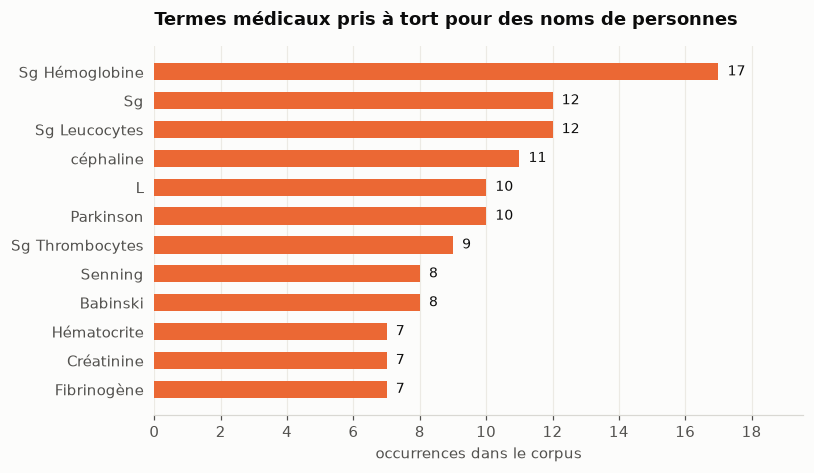

In [7]:
from triage.data.lexique_medical import est_faux_positif

# On isole les termes que le filtre écarte, pour montrer *ce que* spaCy confond.
ecartes = Counter()
for t in textes:
    for r in brut.analyser(t, "fr", entites=("PERSON",)):
        if est_faux_positif(t, r.start, r.end):
            ecartes[t[r.start:r.end].strip()] += 1

top_ecartes = pd.Series(dict(ecartes.most_common(12))).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 4.4))
barres = ax.barh(top_ecartes.index, top_ecartes.values, color=ORANGE, height=0.6)
ax.bar_label(barres, fmt="%d", padding=6, color=ENCRE, fontsize=9)
ax.set_title("Termes médicaux pris à tort pour des noms de personnes", loc="left")
ax.set_xlabel("occurrences dans le corpus")
ax.set_xlim(0, top_ecartes.max() * 1.15)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.grid(axis="y", visible=False)
ax.tick_params(left=False)
plt.tight_layout()
plt.show()

Éponymes (**Parkinson**, **Babinski**, **Senning**), analyses biologiques
(**Hémoglobine**, **Créatinine**), signes cliniques (**Cyanose**) : masquer ces
termes reviendrait à écrire « signe de `<PATIENT>` » et détruirait l'information
qui fonde le diagnostic.

Le filtre `src/triage/data/lexique_medical.py` les écarte selon quatre règles :
majuscule initiale, token isolé, appartenance au lexique médical, et contexte
d'éponyme (`maladie de`, `signe de`, `indice de`…).

### Contrôle visuel avant / après

In [8]:
exemples = [t for t in textes if "Madame" in t or "Monsieur" in t][:2]

for i, texte in enumerate(exemples, 1):
    resultat = filtre.anonymiser(texte, "fr")
    print(f"{'═' * 76}\nCAS {i} — entités retirées : {resultat.entites}\n{'═' * 76}")
    print(f"AVANT\n{texte.strip()[:520]}\n")
    print(f"APRÈS\n{resultat.texte.strip()[:520]}\n")

════════════════════════════════════════════════════════════════════════════
CAS 1 — entités retirées : {'PERSON': 1, 'FR_CIVILITE': 1}
════════════════════════════════════════════════════════════════════════════
AVANT
Madame Sylviane B., 62 ans vient vous consulter pour une paralysie faciale gauche apparue 48 heures auparavant. A l’examen, la patiente est apyrétique. Sa tension artérielle est de 145/85. Elle présente une surcharge pondérale à 78 Kg pour 1m68 mais a perdu 5 Kg en 2 semaines. Dans ces antécédents, vous notez un diabète insulino-dépendant et une hypertension artérielle traitée par Loxen®.

APRÈS
<PATIENT>, 62 ans vient vous consulter pour une paralysie faciale gauche apparue 48 heures auparavant. A l’examen, la patiente est apyrétique. Sa tension artérielle est de 145/85. Elle présente une surcharge pondérale à 78 Kg pour 1m68 mais a perdu 5 Kg en 2 semaines. Dans ces antécédents, vous notez un diabète insulino-dépendant et une hypertension artérielle traitée par Loxen®.

## 5. Résultat du contrôle qualité

Le contrôle industrialisé (`src/triage/data/qc_anonymisation.py`) anonymise puis
**ré-analyse la sortie** : toute entité identifiante encore détectée est un résidu.
Son rapport est versionné avec le code.

In [9]:
rapport = json.loads((RACINE / "data/manifests/qc_anonymisation_mediqal_oeq.json").read_text())

print(f"textes analysés           : {rapport['nb_textes']}")
print(f"textes contenant des PII  : {rapport['nb_textes_avec_pii']} "
      f"({100 * rapport['nb_textes_avec_pii'] / rapport['nb_textes']:.1f} %)")
print(f"taux de PII résiduelle    : {100 * rapport['taux_residuel']:.2f} %\n")
pd.Series(rapport["entites_retirees"]).sort_values(ascending=False).rename("entités retirées").to_frame()

textes analysés           : 1011
textes contenant des PII  : 502 (49.7 %)
taux de PII résiduelle    : 0.20 %



,entités retirées
PERSON,534
FR_CIVILITE,422
ETABLISSEMENT_SANTE,226
FR_DATE_ABSOLUE,16
PHONE_NUMBER,4


In [10]:
for exemple in rapport["exemples_residus"]:
    print(f"[{exemple['entite']}] détecté : {exemple['detecte']!r}")
    print(f"   contexte : {exemple['extrait'][:100]!r}\n")

[PERSON] détecté : 'PATIENT>/L'
   contexte : '(g/L) 1,0\n Sg Leucocytes G/L 6,5\n Sg—Erythrocytes T/L 3.7\n <PATIENT>/L 70\n <PATIENT> g/L 105\n Sg-- H'

[PERSON] détecté : 'PATIENT>/L'
   contexte : 't J7 sont les suivants :\n\nJ1\tJ7\nSe CK (UI/L)\t23.400\t82.900\n<PATIENT>/L)\t500\t1.430\nSe LDH (UI/L)\t1.13'



Les résidus portent sur le **marqueur `<PATIENT>` lui-même**, ré-identifié comme
nom propre lorsqu'il jouxte une unité de laboratoire (`<PATIENT>/L`). Aucune donnée
personnelle d'origine ne subsiste.

## 6. Ce que ce lot établit

| Constat | Conséquence |
|---|---|
| L'urgence pèse peu dans le corpus | Les corpus servent de socle de connaissance, pas de jeu de triage |
| Constantes vitales quasi absentes, aucun label de priorité | Un bloc de cas de triage structurés est indispensable |
| Une civilité dans un cas sur quatre | L'anonymisation est nécessaire, pas décorative |
| spaCy confond vocabulaire médical et patronymes | Un filtre d'exclusion médical conditionne la qualité du dataset |
| PII résiduelle à 0,20 %, sans fuite réelle | La chaîne d'anonymisation est validée pour la suite |

**Étape suivante** : construction des blocs SFT et du jeu DPO
(`docs/03c-plan-composition-dataset.md`).